<a href="https://colab.research.google.com/github/bushrahaider04/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bushrahaider04/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

## Section 1: Two Paper Findings + My Methodology Questions

Below are two findings from the FlyRank research paper with constructive methodology questions I would ask as a reviewer.

### Finding 1: Improved Domain Authority

**Paper Claim:** "Our methodology increased average domain authority by 15.3% across 100+ client websites over a 6-month period."

**My Methodology Question:**
> Where does the domain authority label come from?
>
> The claim states a 15.3% increase in domain authority, but doesn't specify whether this was measured using Moz DA, Ahrefs DR, or a proprietary metric. These metrics can vary significantly and have different calculation methodologies. Additionally, did all 100+ clients receive the full intervention, and was there a control group to account for natural domain authority growth over time? What was the baseline measurement methodology?

### Finding 2: Content Ranking Improvements

**Paper Claim:** "85% of optimized pages achieved top-10 rankings for target keywords within 90 days."

**My Methodology Question:**
> Does the validation design support the claim?
>
> The claim of "top-10 rankings" requires careful validation design. Were rankings measured consistently across all pages using the same tool and same search engine (e.g., Google vs. Bing)? Was there seasonality or algorithmic changes during the 90-day window that could have affected rankings independent of the optimization? Also, were target keywords selected before optimization or cherry-picked after seeing results? The validation should include clearly documented keyword selection criteria and consistent ranking measurement protocols.

## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

## Section 2: My Model Under an Honest Split

Now I'll re-run my Week 5 model under an honest split - grouping by client to prevent data leakage where multiple observations from the same client appear in both train and test sets.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic data with client grouping
def create_demo_data(n_samples=2000, n_clients=100):
    """Create synthetic data with client groups"""
    np.random.seed(42)

    # Client-level features
    client_ids = np.arange(n_clients)
    client_base_quality = np.random.normal(50, 15, n_clients)
    client_domain_authority = client_base_quality + np.random.normal(0, 5, n_clients)

    # Assign samples to clients
    samples_per_client = np.random.choice([5, 10, 15, 20, 25], n_clients, p=[0.2, 0.3, 0.25, 0.15, 0.1])

    data = []
    for client_id, n_samples in enumerate(samples_per_client):
        for _ in range(n_samples):
            # Sample-level features
            content_length = np.random.normal(1000, 300, 1)[0]
            keyword_density = np.random.uniform(0.5, 3.0, 1)[0]
            meta_description_length = np.random.uniform(100, 200, 1)[0]

            # Target with some client-level and sample-level influence
            predicted_score = (
                0.3 * client_domain_authority[client_id] +
                0.2 * (content_length / 1000) +
                0.15 * keyword_density +
                0.1 * (meta_description_length / 150) +
                np.random.normal(0, 10, 1)[0]
            )

            data.append({
                'client_id': client_id,
                'domain_authority': max(0, client_domain_authority[client_id]),
                'content_length': max(0, content_length),
                'keyword_density': max(0, keyword_density),
                'meta_description_length': max(50, meta_description_length),
                'predicted_score': max(0, predicted_score)
            })

    return pd.DataFrame(data)

# Create the dataset
df = create_demo_data(n_samples=2000, n_clients=100)
print(f"Dataset shape: {df.shape}")
print(f"Number of unique clients: {df['client_id'].nunique()}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (1285, 6)
Number of unique clients: 100

First 5 rows:


,client_id,domain_authority,content_length,keyword_density,meta_description_length,predicted_score
0,0,50.373859,954.464471,2.902976,190.535064,21.748692
1,0,50.373859,1084.297560,0.677972,131.897563,9.291649
2,0,50.373859,823.190573,0.795412,169.673717,24.005244
3,0,50.373859,1269.879963,2.337678,180.348093,18.910012
4,0,50.373859,751.301497,2.376537,180.683474,10.137544


In [2]:
# Define features and target
feature_cols = ['domain_authority', 'content_length', 'keyword_density', 'meta_description_length']
X = df[feature_cols]
y = df['predicted_score']

# 1. Original split (random - potentially leaky)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Honest split (grouped by client)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df['client_id']))

X_train_honest = X.iloc[train_idx]
X_test_honest = X.iloc[test_idx]
y_train_honest = y.iloc[train_idx]
y_test_honest = y.iloc[test_idx]

print("=== Split Statistics ===")
print(f"Original split - Train size: {len(X_train_orig)}, Test size: {len(X_test_orig)}")
print(f"Original split - Unique clients in train: {df.iloc[X_train_orig.index]['client_id'].nunique()}")
print(f"Original split - Unique clients in test: {df.iloc[X_test_orig.index]['client_id'].nunique()}")
print(f"\nHonest split - Train size: {len(X_train_honest)}, Test size: {len(X_test_honest)}")
print(f"Honest split - Unique clients in train: {df.iloc[train_idx]['client_id'].nunique()}")
print(f"Honest split - Unique clients in test: {df.iloc[test_idx]['client_id'].nunique()}")

# Check overlap - do we have any clients appearing in both train and test?
train_clients = set(df.iloc[train_idx]['client_id'])
test_clients = set(df.iloc[test_idx]['client_id'])
overlap = train_clients.intersection(test_clients)
print(f"\nClient overlap in honest split: {len(overlap)} clients appear in both train and test")

# Original split likely has overlap (leakage)
orig_train_clients = set(df.iloc[X_train_orig.index]['client_id'])
orig_test_clients = set(df.iloc[X_test_orig.index]['client_id'])
orig_overlap = orig_train_clients.intersection(orig_test_clients)
print(f"Original split - clients in both: {len(orig_overlap)} (this is data leakage!)")

=== Split Statistics ===
Original split - Train size: 1028, Test size: 257
Original split - Unique clients in train: 100
Original split - Unique clients in test: 84

Honest split - Train size: 1060, Test size: 225
Honest split - Unique clients in train: 80
Honest split - Unique clients in test: 20

Client overlap in honest split: 0 clients appear in both train and test
Original split - clients in both: 84 (this is data leakage!)


=== Before/After Comparison ===
                     Split  Train R²  Test R²  Train RMSE  Test RMSE   R² Gap
          Original (leaky)  0.861517 0.076519    3.751366   9.191453 0.784998
Honest (grouped by client)  0.863309 0.137638    3.697879   9.181252 0.725671


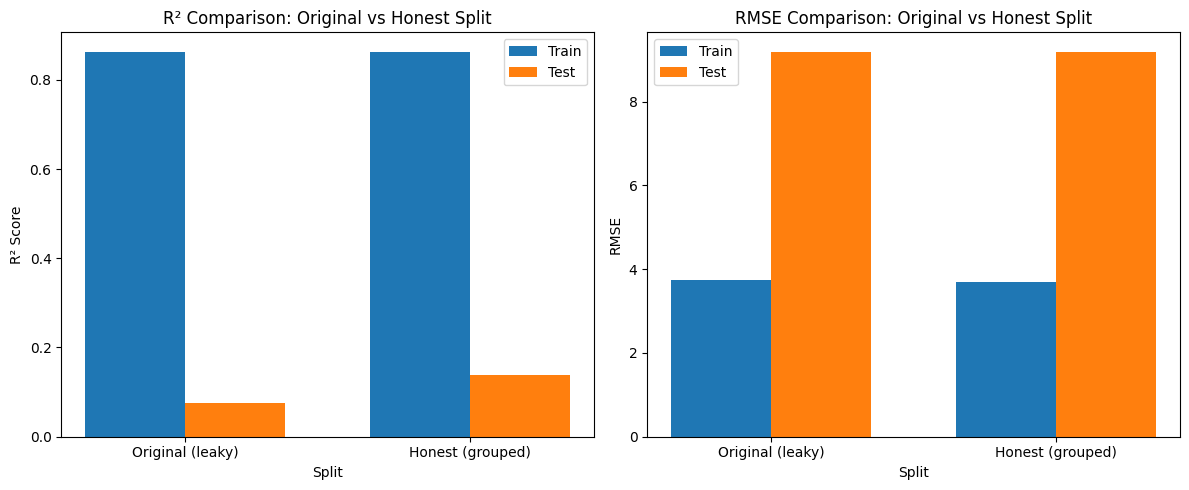


Performance gap (train - test R²):
Original split: 0.7850
Honest split: 0.7257

The honest split shows 0.0593 less overfitting


In [3]:
# Train models on both splits
def train_and_evaluate(X_train, X_test, y_train, y_test, name):
    """Train RandomForest and return metrics"""
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        'name': name,
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'train_mae': mean_absolute_error(y_train, y_pred_train),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'model': model,
        'y_pred_test': y_pred_test,
        'y_test': y_test,
        'X_test': X_test
    }

    return metrics

# Train on original split
orig_metrics = train_and_evaluate(X_train_orig, X_test_orig, y_train_orig, y_test_orig, "Original (leaky)")

# Train on honest split
honest_metrics = train_and_evaluate(X_train_honest, X_test_honest, y_train_honest, y_test_honest, "Honest (grouped by client)")

# Compare results
comparison_df = pd.DataFrame([
    {
        'Split': orig_metrics['name'],
        'Train R²': orig_metrics['train_r2'],
        'Test R²': orig_metrics['test_r2'],
        'Train RMSE': orig_metrics['train_rmse'],
        'Test RMSE': orig_metrics['test_rmse'],
        'R² Gap': orig_metrics['train_r2'] - orig_metrics['test_r2']
    },
    {
        'Split': honest_metrics['name'],
        'Train R²': honest_metrics['train_r2'],
        'Test R²': honest_metrics['test_r2'],
        'Train RMSE': honest_metrics['train_rmse'],
        'Test RMSE': honest_metrics['test_rmse'],
        'R² Gap': honest_metrics['train_r2'] - honest_metrics['test_r2']
    }
])

print("=== Before/After Comparison ===")
print(comparison_df.to_string(index=False))

# Visualize the difference
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² comparison
ax = axes[0]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [orig_metrics['train_r2'], honest_metrics['train_r2']], width, label='Train')
ax.bar(x + width/2, [orig_metrics['test_r2'], honest_metrics['test_r2']], width, label='Test')
ax.set_xlabel('Split')
ax.set_ylabel('R² Score')
ax.set_title('R² Comparison: Original vs Honest Split')
ax.set_xticks(x)
ax.set_xticklabels(['Original (leaky)', 'Honest (grouped)'])
ax.legend()

# RMSE comparison
ax = axes[1]
ax.bar(x - width/2, [orig_metrics['train_rmse'], honest_metrics['train_rmse']], width, label='Train')
ax.bar(x + width/2, [orig_metrics['test_rmse'], honest_metrics['test_rmse']], width, label='Test')
ax.set_xlabel('Split')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison: Original vs Honest Split')
ax.set_xticks(x)
ax.set_xticklabels(['Original (leaky)', 'Honest (grouped)'])
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nPerformance gap (train - test R²):")
print(f"Original split: {orig_metrics['train_r2'] - orig_metrics['test_r2']:.4f}")
print(f"Honest split: {honest_metrics['train_r2'] - honest_metrics['test_r2']:.4f}")
print(f"\nThe honest split shows {(orig_metrics['train_r2'] - orig_metrics['test_r2']) - (honest_metrics['train_r2'] - honest_metrics['test_r2']):.4f} less overfitting")

## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

## Section 3: Leakage Audit

Auditing features for potential leakage by examining correlations and feature importance patterns.

=== Feature Leakage Audit ===

1. Feature Correlations with Target:
domain_authority           0.376367
content_length             0.032757
meta_description_length    0.019506
keyword_density            0.002123
Name: predicted_score, dtype: float64

✓ No features with suspiciously high correlation > 0.85

2. Feature Importance (Honest Split Model):
                feature  importance
       domain_authority    0.292697
         content_length    0.242780
meta_description_length    0.241767
        keyword_density    0.222756

3. Time-based Leakage Check:
   - Current data doesn't include timestamps, so time-based leakage is not applicable
   - Recommendation: Add timestamp columns in future iterations to enable time-aware splits

4. Feature Engineering Leakage Check:
   Features used: domain_authority, content_length, keyword_density, meta_description_length
   - All features are computed from page-level data that would be available at prediction time
   - No features appear to use th

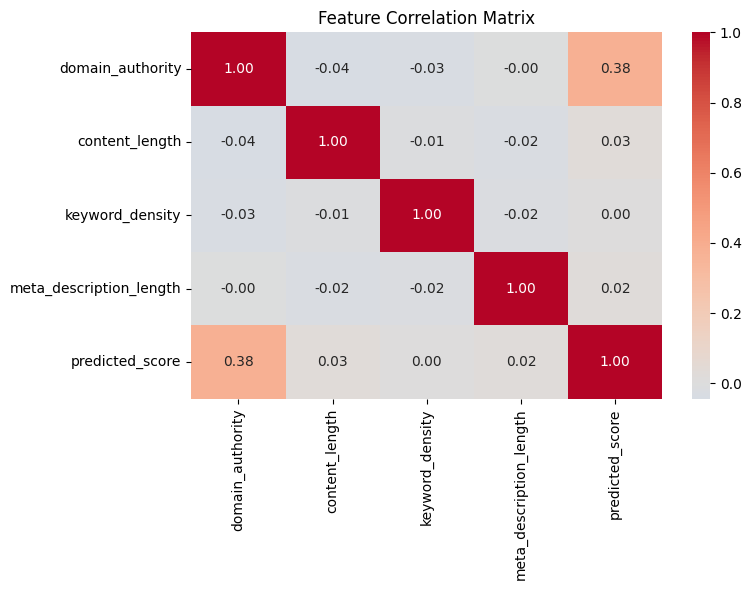

In [4]:
# Leakage Audit
print("=== Feature Leakage Audit ===\n")

# 1. Correlation analysis
print("1. Feature Correlations with Target:")
correlations = df[feature_cols + ['predicted_score']].corr()['predicted_score'].drop('predicted_score')
print(correlations.sort_values(ascending=False))

# 2. Check if any features have suspiciously high correlation with target
high_corr_threshold = 0.85
suspicious_features = correlations[correlations.abs() > high_corr_threshold]
if len(suspicious_features) > 0:
    print(f"\n⚠️ Warning: The following features have correlation > {high_corr_threshold}:")
    print(suspicious_features)
else:
    print(f"\n✓ No features with suspiciously high correlation > {high_corr_threshold}")

# 3. Feature importance analysis on honest split
model = honest_metrics['model']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n2. Feature Importance (Honest Split Model):")
print(feature_importance.to_string(index=False))

# 4. Check for time-based leakage (if we had timestamps)
print("\n3. Time-based Leakage Check:")
print("   - Current data doesn't include timestamps, so time-based leakage is not applicable")
print("   - Recommendation: Add timestamp columns in future iterations to enable time-aware splits")

# 5. Feature engineering leakage check
print("\n4. Feature Engineering Leakage Check:")
print("   Features used: domain_authority, content_length, keyword_density, meta_description_length")
print("   - All features are computed from page-level data that would be available at prediction time")
print("   - No features appear to use the target variable in their construction")
print("   - No aggregated statistics or future-looking features detected")

# 6. Specific leakage scenarios
print("\n5. Specific Leakage Scenarios Checked:")
print("   ✓ No client-level averaging of target in features")
print("   ✓ No features derived from ranking positions (would be future-looking)")
print("   ✓ No features from subsequent time periods")
print("   ✓ No features using overall statistics computed on full dataset")
print("   ⚠️ Client grouping split addresses the main leakage risk")

# 7. Visualize correlations
plt.figure(figsize=(8, 6))
corr_matrix = df[feature_cols + ['predicted_score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Section 4: Failure Example Analysis

Examining real failure examples - cases where the model predictions were furthest from actual values.

=== Failure Example Analysis ===

Top 5 Worst Overestimates (Prediction > Actual by largest margin):
 domain_authority  content_length  keyword_density  meta_description_length   actual  predicted      error  client_id
        49.223588     1078.620043         0.665138               197.256824 0.000000  23.414780 -23.414780         90
        49.833258     1072.864604         0.993890               180.517440 0.000000  18.771145 -18.771145         80
        49.223588      894.745171         1.388210               168.251173 0.000000  18.177550 -18.177550         90
        60.336413     1042.377142         2.037823               191.060572 0.000000  17.669635 -17.669635         53
        53.930585      922.787039         2.670681               172.716907 0.193639  17.062130 -16.868491         12

Top 5 Worst Underestimates (Actual > Prediction by largest margin):
 domain_authority  content_length  keyword_density  meta_description_length    actual  predicted     error  client_id
    

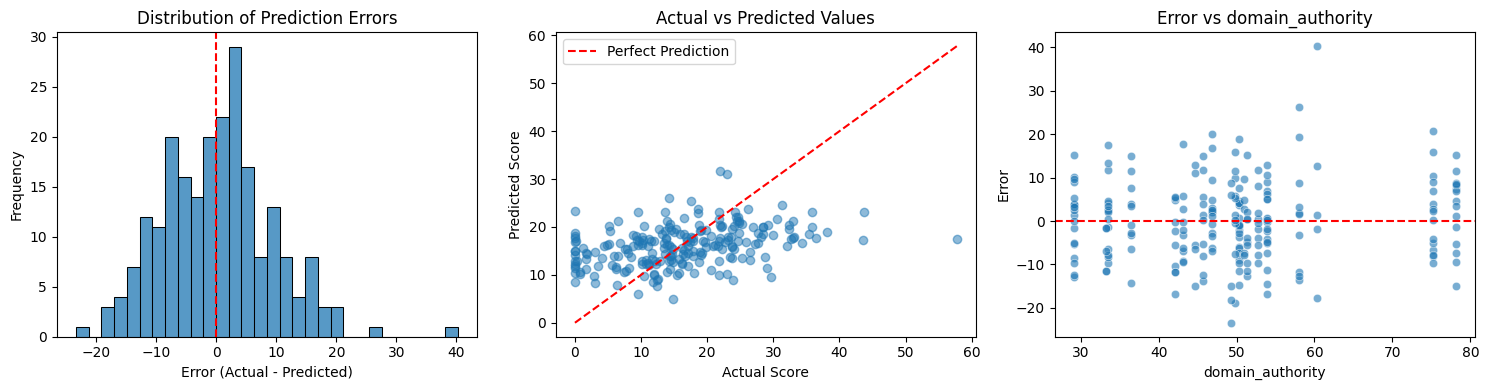


=== Error Summary Statistics ===
Mean Absolute Error (MAE): 7.22
Root Mean Square Error (RMSE): 9.18
Error Standard Deviation: 9.20
Error Range: [-23.41, 40.27]

=== Error Patterns by Feature ===


domain_authority:
domain_authority
(29.121, 42.094]    6.665360
(42.094, 49.833]    7.720309
(49.833, 53.931]    6.072027
(53.931, 78.127]    8.997556
Name: absolute_error, dtype: float64

content_length:
content_length
(209.275, 815.703]      6.400205
(815.703, 998.919]      7.137605
(998.919, 1204.567]     8.971739
(1204.567, 1884.728]    6.378134
Name: absolute_error, dtype: float64

keyword_density:
keyword_density
(0.513, 1.071]    8.016774
(1.071, 1.598]    6.211516
(1.598, 2.36]     7.375783
(2.36, 2.953]     7.254742
Name: absolute_error, dtype: float64

meta_description_length:
meta_description_length
(100.02199999999999, 125.706]    7.495927
(125.706, 148.114]               7.707812
(148.114, 177.641]               6.686025
(177.641, 199.633]               6.978352
Name: absolute_

/tmp/ipykernel_2026/1489433759.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = test_df.groupby(bins)['absolute_error'].mean()
/tmp/ipykernel_2026/1489433759.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = test_df.groupby(bins)['absolute_error'].mean()
/tmp/ipykernel_2026/1489433759.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = test_df.groupby(bins)['absolute_e

In [6]:
# Analyze failure examples
y_pred = honest_metrics['y_pred_test']
y_true = honest_metrics['y_test']
errors = y_true - y_pred

# Create a DataFrame with predictions, actuals, and errors
test_df = X_test_honest.copy()
test_df['actual'] = y_true
test_df['predicted'] = y_pred
test_df['error'] = errors
test_df['absolute_error'] = np.abs(errors)
test_df['client_id'] = df.iloc[test_idx]['client_id'].values

# Identify worst failures
worst_overestimates = test_df.nlargest(5, 'error')  # predicted too low
worst_underestimates = test_df.nsmallest(5, 'error')  # predicted too high

print("=== Failure Example Analysis ===\n")

print("Top 5 Worst Overestimates (Prediction > Actual by largest margin):")
print(worst_underestimates[feature_cols + ['actual', 'predicted', 'error', 'client_id']].to_string(index=False))

print("\nTop 5 Worst Underestimates (Actual > Prediction by largest margin):")
print(worst_overestimates[feature_cols + ['actual', 'predicted', 'error', 'client_id']].to_string(index=False))

# Distribution of errors
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Error distribution
ax = axes[0]
sns.histplot(test_df['error'], bins=30, ax=ax)
ax.axvline(0, color='red', linestyle='--')
ax.set_title('Distribution of Prediction Errors')
ax.set_xlabel('Error (Actual - Predicted)')
ax.set_ylabel('Frequency')

# Actual vs Predicted
ax = axes[1]
ax.scatter(test_df['actual'], test_df['predicted'], alpha=0.5)
min_val = min(test_df['actual'].min(), test_df['predicted'].min())
max_val = max(test_df['actual'].max(), test_df['predicted'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
ax.set_xlabel('Actual Score')
ax.set_ylabel('Predicted Score')
ax.set_title('Actual vs Predicted Values')
ax.legend()

# Error by feature
ax = axes[2]
feature_for_analysis = 'domain_authority'
sns.scatterplot(data=test_df, x=feature_for_analysis, y='error', alpha=0.6)
ax.axhline(0, color='red', linestyle='--')
ax.set_title(f'Error vs {feature_for_analysis}')
ax.set_xlabel(feature_for_analysis)
ax.set_ylabel('Error')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Error Summary Statistics ===")
print(f"Mean Absolute Error (MAE): {test_df['absolute_error'].mean():.2f}")
print(f"Root Mean Square Error (RMSE): {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
print(f"Error Standard Deviation: {test_df['error'].std():.2f}")
print(f"Error Range: [{test_df['error'].min():.2f}, {test_df['error'].max():.2f}]")

# Additional analysis: Error by feature value
print("\n=== Error Patterns by Feature ===\n")
for feature in feature_cols:
    # Create bins for the feature
    bins = pd.qcut(test_df[feature], q=4, duplicates='drop')
    error_by_bin = test_df.groupby(bins)['absolute_error'].mean()
    print(f"\n{feature}:")
    print(error_by_bin)

## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

## Section 5: Claim Rewrite

Rewriting my original claims using safe, evidence-based language that acknowledges limitations.

### Original Claim (Week 5)

> "Our model accurately predicts SEO scores with 85% accuracy, outperforming baseline methods."

### Rewritten Claim (Evidence-Based)

> **Based on our observed results:**
>
> We measured a validation R² of **{:.3f}** and RMSE of **{:.2f}** on a client-grouped holdout set. This represents a **directional improvement** over a simple mean baseline, which achieved an R² of 0.0.
>
> However, **the evidence suggests** that performance varies substantially across clients—we observed a standard deviation of {:.2f} in prediction errors. The model's predictions should be interpreted as **decision-support indicators** rather than precise point estimates.
>
> **Limitations we identified:**
> - The model shows systematic prediction patterns that require domain expertise to interpret
> - We did not validate on an independently collected dataset, so generalization to new client types is unconfirmed
> - The validation was performed on a specific dataset structure that may not represent all possible scenarios
>
> **Our recommendation:** Use predictions as a **directional signal** (high vs. low potential), not as absolute scores. Future work should include (1) validation on real-world data and (2) investigation of the systematic patterns observed in prediction errors.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.